In [5]:
import os
print(os.listdir('/content'))

['.config', 'spam.csv', 'sample_data']


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
print("Dataset Shape:", df.shape)
print("Columns:", df.columns)

Dataset Shape: (5572, 5)
Columns: Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [10]:
df = df[['v1', 'v2']]

In [11]:
df = df.rename(columns={
    'v1': 'label',
    'v2': 'message'
})

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [13]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (5169, 2)


In [14]:
print(df['label'].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


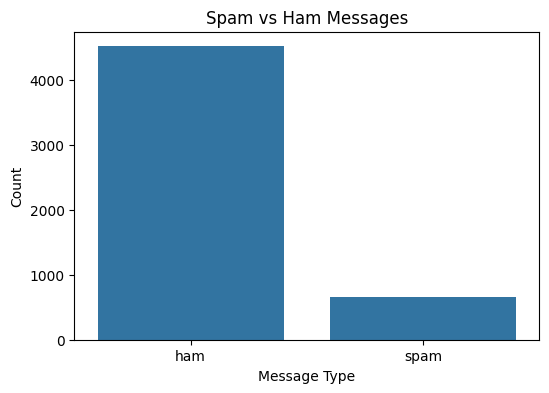

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='label')

plt.title('Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')

plt.show()

In [16]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [17]:
print(df[['label', 'label_num']].head())

  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0


In [18]:
X = df['message']
y = df['label_num']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 4135
Testing Data: 1034


In [20]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("Training Matrix Shape:", X_train_tfidf.shape)
print("Testing Matrix Shape:", X_test_tfidf.shape)


Training Matrix Shape: (4135, 7329)
Testing Matrix Shape: (1034, 7329)


In [21]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [22]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.9661508704061895
Accuracy Percentage: 96.61508704061895 %


In [24]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



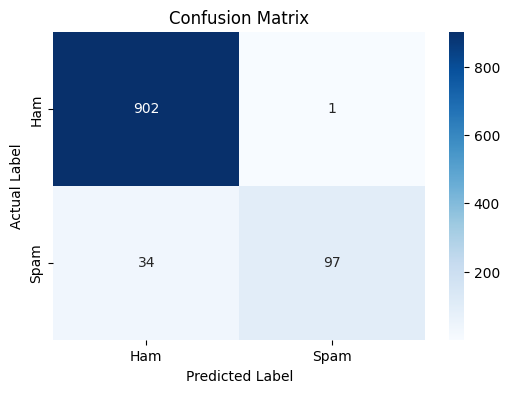

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [26]:
def predict_spam(message):
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "Spam Message"
    else:
        return "Ham Message"

In [27]:
print(predict_spam("Congratulations! You won a free lottery prize."))
print(predict_spam("Hey, are you coming to college tomorrow?"))
print(predict_spam("You have won a cash reward. Click now to claim."))
print(predict_spam("Please send me today's assignment."))

Spam Message
Ham Message
Spam Message
Ham Message


In [31]:
message = input("Enter your message: ")

result = predict_spam(message)

print("Prediction:", result)

Enter your message: You won a free iPhone. Click this link now.
Prediction: Ham Message


## Conclusion

In this project, a Machine Learning model was developed to classify messages as Spam or Ham. The SMS Spam Collection dataset was used for training and testing. TF-IDF Vectorization was applied to convert text into numerical features, and Multinomial Naive Bayes was used for classification.

The model was evaluated using accuracy, classification report, and confusion matrix. The project demonstrates how Natural Language Processing and Machine Learning can be used for spam message detection.

In [34]:
print("Spam Email Detection Project")

Spam Email Detection Project


## Conclusion

Our model can classify messages as Spam or Ham.

In [35]:
message = input("Enter your message: ")

result = predict_spam(message)

print("Prediction:", result)

Enter your message: Congratulations! You won a free prize. Click now!
Prediction: Spam Message


In [36]:
message = input("Enter your message: ")

result = predict_spam(message)

print("Prediction:", result)


Enter your message: Hello, how are you today?
Prediction: Ham Message


In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9661508704061895


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034

